<a href="https://colab.research.google.com/github/hegde-shashi/arecanut_proejct/blob/main/betelnet_grouping/betelnut_grouping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
!pip install keras-tuner tensorflow tensorboard matplotlib seaborn scikit-learn

In [22]:
import tensorflow as tf
# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPU Devices: ", tf.config.list_physical_devices('GPU'))

# Force GPU usage (if available)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)
else:
    print("⚠ No GPU found - running on CPU")

Num GPUs Available:  1
GPU Devices:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Physical devices cannot be modified after being initialized


In [3]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dense, Dropout, Flatten
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import keras

In [4]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64
CHANNELS = 3
EPOCHS = 50

In [5]:
# data_path = '/content/drive/MyDrive/Arecanut_project/dataset/Betelnet'

data_path = '/Users/shashidharhegde/Developer/DeepLearning/Betelnet'

In [6]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    shuffle=True,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

Found 8428 files belonging to 5 classes.


2026-05-06 13:55:15.312539: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-06 13:55:15.312559: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-06 13:55:15.312567: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-06 13:55:15.312580: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-06 13:55:15.312591: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [7]:
dataset.class_names

['Bette', 'Chaali', 'Chaali_2nd', 'Maani', 'laddu']

In [8]:
len(dataset)

132

In [9]:
image_batch_display, label_batch_display = next(iter(dataset))

In [10]:
print(image_batch_display.shape)
print(label_batch_display.numpy())

(64, 224, 224, 3)
[4 1 4 1 0 2 4 4 2 2 4 2 1 3 2 4 3 3 0 1 3 3 1 1 1 1 1 1 2 2 2 0 4 2 1 4 4
 0 1 3 0 2 1 1 3 4 2 3 3 1 2 1 4 2 4 0 1 2 2 2 3 0 2 1]


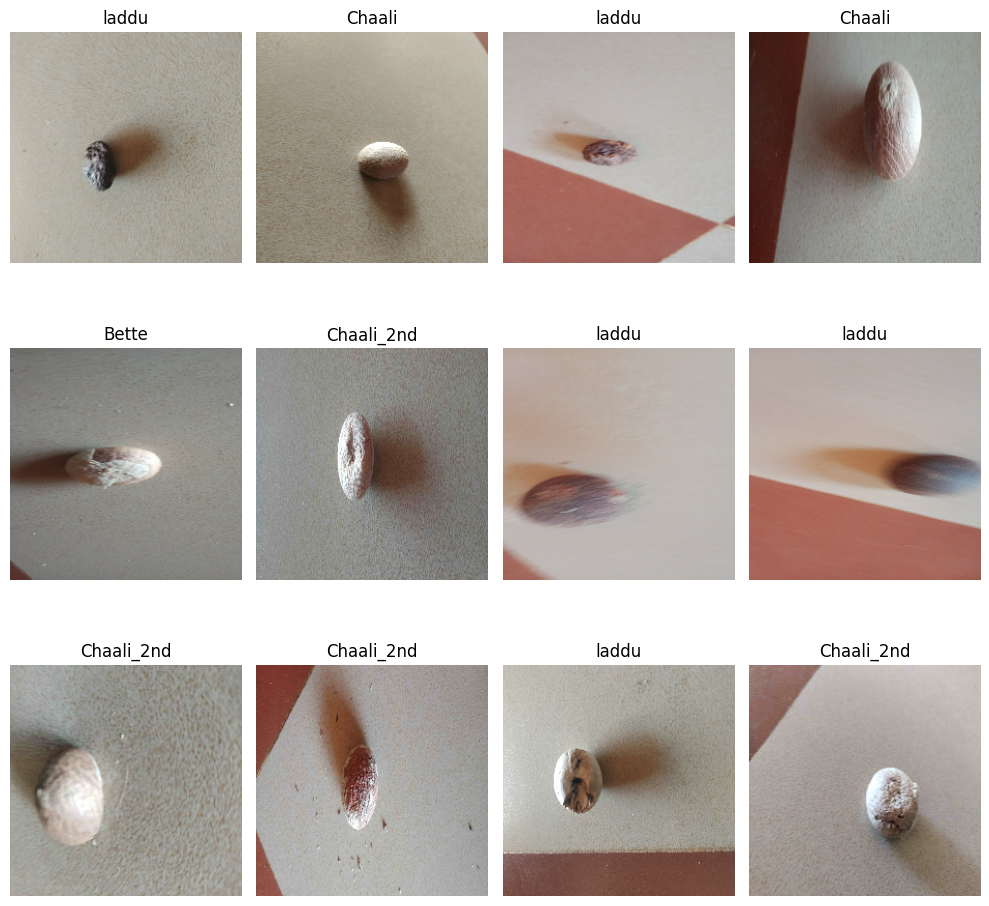

In [11]:
plt.figure(figsize=(10,10))
for i in range(12):
  ax = plt.subplot(3, 4, i+1)
  plt.imshow(image_batch_display[i].numpy().astype('uint8'))
  plt.title(dataset.class_names[label_batch_display[i]])
  plt.axis("off")
plt.tight_layout()

In [12]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

print(f"Total batches: {len(dataset)}")
print(f"Training batches: {train_size}")
print(f"Validation batches: {val_size}")
print(f"Test batches: {test_size}")

Total batches: 132
Training batches: 105
Validation batches: 13
Test batches: 14


### Optimize Dataset Performance
We will use `cache()` and `prefetch()` to optimize the performance of our dataset. `cache()` keeps images in memory after the first epoch, and `prefetch()` overlaps data preprocessing and model execution.

In [13]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + val_split + test_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=42)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)


In [14]:
print("length of train data : ", len(train_ds))
print("length of test data: ", len(val_ds))
print("length of validation data : ", len(test_ds))

length of train data :  105
length of test data:  13
length of validation data :  14


In [15]:
train_ds_prefetch = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds_prefetch = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds_prefetch = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [16]:
data_augmenmtation = Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
])

In [17]:
def compile_model(model, learning_rate):
    model.compile(
        optimizer = Adam(learning_rate),
        loss = 'sparse_categorical_crossentropy',
        metrics = ['accuracy']
    )


def build_custom_cnn_hypermodel(hp):
    inputs = Input(shape=(224, 224, 3))

    x = data_augmenmtation(inputs)
    x = tf.keras.layers.Rescaling(1./255)(x)

    num_conv_blocks = hp.Choice('conv_blocks', [2, 3, 4])
    filter_options = [16, 32, 64, 128, 256]

    prev_filters = hp.Choice('filters_1', [16, 32, 64])
    x = Conv2D(
        prev_filters,
        3,
        padding='same',
        activation='relu',
        kernel_regularizer=l2(1e-4),
    )(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D()(x)

    for block_index in range(1, num_conv_blocks):
        # Allow equal or gradual growth (up to 2x) to support patterns like 32,64,64,128.
        max_next = min(prev_filters * 2, 256)
        valid_filters = [f for f in filter_options if prev_filters <= f <= max_next]
        filters = hp.Choice(f'filters_{block_index + 1}', valid_filters)

        x = Conv2D(
            filters,
            3,
            padding='same',
            activation='relu',
            kernel_regularizer=l2(1e-4),
        )(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D()(x)
        prev_filters = filters

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = Dense(
        units = hp.Choice('dense_units', [128, 256, 512]),
        activation = 'relu'
    )(x)
    x = Dropout(hp.Float('dropout_rate', 0.2, 0.5, step=0.1))(x)

    outputs = Dense(len(dataset.class_names), activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='custom_cnn')
    compile_model(model, hp.Float('lr', 1e-4, 1e-2, sampling='log'))
    return model


def build_mobilenetv2_model(num_classes):
    inputs = Input(shape=(224, 224, 3))

    x = data_augmenmtation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = Dropout(0.25)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='mobilenetv2_transfer')
    return model, base_model


def make_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1),
        ModelCheckpoint(f'best_betelnet_{model_name}.keras', monitor='val_accuracy', mode='max', save_best_only=True),
    ]


def train_mobilenetv2(train_ds, val_ds, test_ds, num_classes):
    model, base_model = build_mobilenetv2_model(num_classes)
    compile_model(model, learning_rate=1e-3)

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=make_callbacks('mobilenetv2_head'),
        verbose=1,
    )

    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    compile_model(model, learning_rate=1e-5)
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=make_callbacks('mobilenetv2_finetuned'),
        verbose=1,
    )

    loss, accuracy = model.evaluate(test_ds, verbose=0)
    print(f'MobileNetV2 test loss: {loss:.4f}')
    print(f'MobileNetV2 test accuracy: {accuracy:.4f}')
    return model, loss, accuracy

In [18]:
num_classes = len(dataset.class_names)
custom_tuner = kt.RandomSearch(
    build_custom_cnn_hypermodel,
    objective = 'val_accuracy',
    max_trials = 8,
    directory = 'betelnet_tuning',
    project_name = 'custom_cnn_tuning',
)

custom_tuner.search(
    train_ds_prefetch,
    validation_data = val_ds_prefetch,
    epochs = 10,
    callbacks = make_callbacks('custom_cnn_search'),
)

custom_tuner.results_summary()
custom_best_hp = custom_tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best custom CNN hyperparameters:', custom_best_hp.values)
custom_model = custom_tuner.get_best_models(num_models=1)[0]
custom_history = custom_model.fit(
    train_ds_prefetch,
    validation_data = val_ds_prefetch,
    epochs = EPOCHS,
    callbacks = make_callbacks('custom_cnn_final'),
    verbose = 1,
)
custom_test_loss, custom_test_accuracy = custom_model.evaluate(test_ds_prefetch, verbose=0)
print(f'Custom CNN test loss: {custom_test_loss:.4f}')
print(f'Custom CNN test accuracy: {custom_test_accuracy:.4f}')

Trial 8 Complete [00h 07m 12s]
val_accuracy: 0.6674876809120178

Best val_accuracy So Far: 0.8349753618240356
Total elapsed time: 00h 59m 48s
Results summary
Results in betelnet_tuning/custom_cnn_tuning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0 summary
Hyperparameters:
conv_blocks: 4
filters_1: 64
filters_2: 32
dense_units: 128
dropout_rate: 0.2
lr: 0.002601283675780245
filters_3: 32
filters_4: 32
Score: 0.8349753618240356

Trial 4 summary
Hyperparameters:
conv_blocks: 4
filters_1: 16
filters_2: 16
dense_units: 128
dropout_rate: 0.2
lr: 0.00234849423835777
filters_3: 32
filters_4: 64
Score: 0.8017241358757019

Trial 6 summary
Hyperparameters:
conv_blocks: 3
filters_1: 16
filters_2: 32
dense_units: 512
dropout_rate: 0.2
lr: 0.0020953695537578336
filters_3: 32
filters_4: 64
Score: 0.7635468244552612

Trial 2 summary
Hyperparameters:
conv_blocks: 3
filters_1: 16
filters_2: 16
dense_units: 512
dropout_rate: 0.4
lr: 0.003467461412492639
filters_3: 64
fi

/opt/anaconda3/envs/datascience/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


105/105 ━━━━━━━━━━━━━━━━━━━━ 69s 632ms/step - accuracy: 0.7839 - loss: 0.6384 - val_accuracy: 0.3399 - val_loss: 12.7994 - learning_rate: 0.0026
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 65s 620ms/step - accuracy: 0.7855 - loss: 0.6497 - val_accuracy: 0.6047 - val_loss: 1.8195 - learning_rate: 0.0026
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 66s 629ms/step - accuracy: 0.7919 - loss: 0.6236 - val_accuracy: 0.2020 - val_loss: 62.8221 - learning_rate: 0.0026
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 66s 630ms/step - accuracy: 0.8157 - loss: 0.5688 - val_accuracy: 0.2685 - val_loss: 20.3977 - learning_rate: 0.0026
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.8223 - loss: 0.5458
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00026012836024165155.
105/105 ━━━━━━━━━━━━━━━━━━━━ 67s 631ms/step - accuracy: 0.8160 - loss: 0.5784 - val_accuracy: 0.5517 - val_loss: 2.3818 - learning_rate: 0.0026
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 65s 610ms/step - accuracy: 0.8579 - los

2026-05-06 15:37:31.560424: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:8: Filling up shuffle buffer (this may take a while): 124 of 10000
2026-05-06 15:37:32.195479: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


Custom CNN test loss: 0.2800
Custom CNN test accuracy: 0.9174


In [19]:
mobilenet_model, mobilenet_test_loss, mobilenet_test_accuracy = train_mobilenetv2(
    train_ds_prefetch,
    val_ds_prefetch,
    test_ds_prefetch,
    num_classes,
)

best_model = mobilenet_model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 47s 404ms/step - accuracy: 0.6646 - loss: 0.8751 - val_accuracy: 0.8165 - val_loss: 0.5623 - learning_rate: 0.0010
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 31s 291ms/step - accuracy: 0.7910 - loss: 0.5662 - val_accuracy: 0.8448 - val_loss: 0.4891 - learning_rate: 0.0010
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 31s 299ms/step - accuracy: 0.8242 - loss: 0.4946 - val_accuracy: 0.8682 - val_loss: 0.4133 - learning_rate: 0.0010
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 31s 300ms/step - accuracy: 0.8346 - loss: 0.4388 - val_accuracy: 0.8879 - val_loss: 0.3770 - learning_rate: 0.0010
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 32s 300ms/step - accuracy: 0.8519 - loss: 0.4093 - val_accuracy: 0.8805 - val_loss: 0.3816 - learning_rate: 0.0010
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 31s 294ms/step - accuracy: 0.8657 - loss: 0.3853 - val_accuracy: 0.8781 - val_loss: 0.3755 - learning_rate: 0.0010
Epoch 7/15
105/105 ━━

In [20]:
print('=== Model Comparison ===')
print(f'Custom CNN test accuracy: {custom_test_accuracy:.4f}')
print(f'Custom CNN test loss: {custom_test_loss:.4f}')
print(f'MobileNetV2 test accuracy: {mobilenet_test_accuracy:.4f}')
print(f'MobileNetV2 test loss: {mobilenet_test_loss:.4f}')

=== Model Comparison ===
Custom CNN test accuracy: 0.9174
Custom CNN test loss: 0.2800
MobileNetV2 test accuracy: 0.9174
MobileNetV2 test loss: 0.2316


In [21]:
print('Both models have already been trained above.')
print('Use custom_model for the custom CNN results and best_model for MobileNetV2.')

Both models have already been trained above.
Use custom_model for the custom CNN results and best_model for MobileNetV2.


In [23]:
# Validate the model on the test set
test_loss, test_accuracy = best_model.evaluate(test_ds_prefetch)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - accuracy: 0.9174 - loss: 0.2316
Test Loss: 0.2316
Test Accuracy: 0.9174


14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 343ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       194
           1       0.94      0.86      0.90       197
           2       0.80      0.95      0.87       173
           3       0.95      0.96      0.96       169
           4       0.93      0.90      0.92       163

    accuracy                           0.92       896
   macro avg       0.92      0.92      0.92       896
weighted avg       0.92      0.92      0.92       896

Confusion Matrix:
[[178   0   8   5   3]
 [  0 170  21   3   3]
 [  0   5 164   0   4]
 [  1   2   2 163   1]
 [  2   3  10   1 147]]


2026-05-06 23:52:07.938006: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


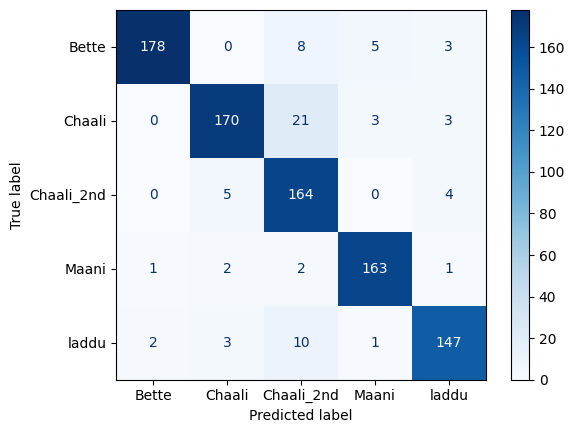

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pred = best_model.predict(test_ds_prefetch)
predicted_labels = np.argmax(pred, axis=1)
true_labels = np.concatenate([y for x, y in test_ds_prefetch], axis=0)

print("Classification Report:")
print(classification_report(true_labels, predicted_labels))



print("Confusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

display(ConfusionMatrixDisplay.from_predictions(true_labels, predicted_labels, display_labels=dataset.class_names, cmap=plt.cm.Blues))

In [28]:
import tempfile


def build_tflite_export_model(model):
    inputs = tf.keras.Input(shape=model.input_shape[1:])
    x = inputs
    inserted_mobilenet_preprocess = False

    for layer in model.layers:
        layer_name = layer.__class__.__name__.lower()
        if layer_name == 'inputlayer':
            continue

        # Drop training-time augmentation layers from the export graph.
        if layer_name == 'sequential':
            continue

        # Recreate MobileNet preprocessing explicitly because it is not stored as a layer.
        if not inserted_mobilenet_preprocess and 'mobilenet' in layer.name.lower():
            x = tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input)(x)
            inserted_mobilenet_preprocess = True

        if isinstance(layer, tf.keras.Model):
            x = layer(x, training=False)
        else:
            x = layer(x)

    return tf.keras.Model(inputs=inputs, outputs=x, name=f'{model.name}_tflite_export')


def save_tflite_model(model, output_path, quantization='dynamic', representative_data=None):
    export_model = build_tflite_export_model(model)
    export_dir = tempfile.mkdtemp(prefix='tflite_export_')
    export_model.export(export_dir)

    converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)

    if quantization == 'dynamic':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
    elif quantization == 'fp16':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
    elif quantization == 'int8':
        if representative_data is None:
            raise ValueError('representative_data is required for int8 quantization')
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_data
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
    else:
        raise ValueError("quantization must be one of: 'dynamic', 'fp16', 'int8'")

    tflite_model = converter.convert()
    with open(output_path, 'wb') as file_handle:
        file_handle.write(tflite_model)

    print(f'Saved TFLite model to {output_path}')


# Dynamic-range quantization is the safest default because it does not need calibration data.
save_tflite_model(custom_model, 'betelnet_custom_cnn_dynamic.tflite', quantization='dynamic')
save_tflite_model(best_model, 'betelnet_mobilenetv2_dynamic.tflite', quantization='dynamic')

# Optional: uncomment if you want a smaller FP16 model.
# save_tflite_model(custom_model, 'betelnet_custom_cnn_fp16.tflite', quantization='fp16')
# save_tflite_model(best_model, 'betelnet_mobilenetv2_fp16.tflite', quantization='fp16')

INFO:tensorflow:Assets written to: /var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/tflite_export_vxjqnvvv/assets


INFO:tensorflow:Assets written to: /var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/tflite_export_vxjqnvvv/assets


Saved artifact at '/var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/tflite_export_vxjqnvvv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_181')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  20290069680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  20290072144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13202790480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13202791888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13202789248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13202789776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13202791360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13202788192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13202791008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13202791184: TensorSpec(shape=(), dtype=tf.resource, name=Non

W0000 00:00:1778092018.868976 5285675 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1778092018.868992 5285675 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-05-06 23:56:58.869206: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/tflite_export_vxjqnvvv
2026-05-06 23:56:58.870525: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-06 23:56:58.870532: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/tflite_export_vxjqnvvv
2026-05-06 23:56:58.884994: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-05-06 23:56:58.935026: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: /var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/tflite_export_vxjqnvvv
2026-05-06 23:56:58.949603: I ten

Saved TFLite model to betelnet_custom_cnn_dynamic.tflite
INFO:tensorflow:Assets written to: /var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/tflite_export_go8_4dxf/assets


INFO:tensorflow:Assets written to: /var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/tflite_export_go8_4dxf/assets


Saved artifact at '/var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/tflite_export_go8_4dxf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_199')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  13202794000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13166240768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13166239360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13166240240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13166240416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13166238832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13166240592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13166237600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13166240064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13166240944: TensorSpec(shape=(), dtype=tf.resource, name=Non

W0000 00:00:1778092022.514452 5285675 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1778092022.514461 5285675 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-05-06 23:57:02.514604: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/tflite_export_go8_4dxf
2026-05-06 23:57:02.519117: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-06 23:57:02.519125: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/tflite_export_go8_4dxf
2026-05-06 23:57:02.621560: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-05-06 23:57:02.950081: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: /var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/tflite_export_go8_4dxf
2026-05-06 23:57:03.042816: I ten